<h1><center>Stock Analysis</center></h1>

Technical analysis and portfolio construction for five large-cap US technology stocks — **AAPL, MSFT, GOOGL, NVDA, TSLA** — using daily split- and dividend-adjusted prices from Yahoo Finance and the 3-month Treasury yield from FRED.

The notebook runs in two parts.

**Part 1 — Market data and technical analysis**

| Section | What it does |
| --- | --- |
| 1 · Setup | Imports |
| 2 · Load market data | One download of the daily OHLCV panel |
| 3 · Price history | Adjusted close for all five names |
| 4 · Per-ticker frames | Split the panel into one frame per stock |
| 5 · Technical indicators | Bollinger Bands, RSI, MACD, SMA pair, ATR |
| 6 · Moving-average crossovers | Golden and death crosses per stock |
| 7 · Bollinger Bands | Volatility envelope per stock |
| 8 · MACD | Trend and momentum crossovers per stock |

**Part 2 — Portfolio construction**

| Section | What it does |
| --- | --- |
| 9 · Portfolio inputs | Annualized risk, return, correlation, live risk-free rate |
| 10 · Weighting strategies | Equal, inverse-volatility, inverse-variance |
| 11 · Monte Carlo I | 25,000 random portfolios and the efficient frontier |
| 12 · Monte Carlo II | Bootstrap of forward one-year outcomes |
| 13 · Summary | What the results do and do not support |

**Scope note.** Every number here is in-sample: it describes the 2020–present window, not the future. Portfolios are long-only and fully invested (weights ≥ 0, summing to 1). Nothing in this notebook is investment advice.

# Part 1 — Market data and technical analysis

## 1 · Setup

Two plotting libraries are used deliberately: `matplotlib` for the static per-ticker indicator charts in sections 6 and 7, and `plotly` for the interactive multi-series charts where hovering over a specific date or portfolio is useful.

In [80]:
import matplotlib.pyplot as plt      # static per-ticker indicator charts
import numpy as np
import pandas as pd
import plotly.express as px          # quick wide-form charts
import plotly.graph_objects as go    # hand-built figures (frontier scatter, fan chart)
import yfinance as yf
from IPython.display import display

## 2 · Load market data

A single call to `yfinance` pulls daily OHLCV for all five tickers, and the close-only panel used by the portfolio math is derived from it. Downloading once and slicing avoids a second network round trip returning data that must stay consistent with the first.

`auto_adjust=True` back-adjusts prices for splits and dividends. This matters here: several of these names split during the window, and unadjusted prices would show those splits as enormous one-day crashes, corrupting every return calculation downstream.

Two structural details worth noting, because later cells depend on them:

- The returned columns are a **two-level index**, `(Price, Ticker)`.
- `yfinance` orders tickers **alphabetically** regardless of the input list, so the close panel is explicitly reordered to match `tickers`.

In [ ]:
tickers = ['AAPL', 'MSFT', 'GOOGL', 'NVDA', 'TSLA']
start_date = '2020-01-01'
end_date = '2026-07-31'

"""
Single download for the whole notebook. auto_adjust=True back-adjusts for splits and
dividends, so Close is a total-return price and daily percent changes stay comparable
across names (NVDA and AAPL both split during this window).
"""
df = yf.download(
    tickers,
    start=start_date,
    end=end_date,
    interval='1d',
    auto_adjust=True,
)

"""
Close-only panel, one column per ticker, used by the price chart and all portfolio math.
yfinance returns tickers alphabetically, so reorder to match the list above and keep
every downstream table and legend in a consistent order.
"""
data = df.xs('Close', axis=1, level='Price')[tickers]

print(f'{data.shape[0]:,} trading days x {data.shape[1]} tickers')
print(f'{data.index.min():%Y-%m-%d} to {data.index.max():%Y-%m-%d}')
print(f'missing closes: {int(data.isna().sum().sum())}')
data.head()

[*********************100%***********************]  5 of 5 completed

1,652 trading days x 5 tickers
2020-01-02 to 2026-07-30
missing closes: 0


Ticker,AAPL,MSFT,GOOGL,NVDA,TSLA
Date,,,,,
2020-01-02,72.271545,151.544266,67.832512,5.963804,28.684000
2020-01-03,71.568909,149.657257,67.477661,5.868346,29.534000
2020-01-06,72.139183,150.044098,69.276215,5.892957,30.102667
2020-01-07,71.799942,148.676056,69.142403,5.964302,31.270666
2020-01-08,72.954926,151.044220,69.634529,5.975487,32.809334


In [ ]:
""" 
The raw download keeps a two-level column index: level 0 is the price field,
level 1 is the ticker. Section 4 slices it with .xs() on the 'Ticker' level.
"""
print('column levels:', df.columns.names)
print('price fields :', df.columns.get_level_values('Price').unique().tolist())
df.head()

column levels: ['Price', 'Ticker']
price fields : ['Close', 'High', 'Low', 'Open', 'Volume']


Price           Close                                                   High  \
Ticker           AAPL      GOOGL        MSFT      NVDA       TSLA       AAPL   
Date                                                                           
2020-01-02  72.271545  67.832512  151.544266  5.963804  28.684000  72.331702   
2020-01-03  71.568909  67.477661  149.657257  5.868346  29.534000  72.326874   
2020-01-06  72.139183  69.276215  150.044098  5.892957  30.102667  72.177684   
2020-01-07  71.799942  69.142403  148.676056  5.964302  31.270666  72.403904   
2020-01-08  72.954926  69.634529  151.044220  5.975487  32.809334  73.255706   

Price                                                   ...       Open  \
Ticker          GOOGL        MSFT      NVDA       TSLA  ...       AAPL   
Date                                                    ...              
2020-01-02  67.832512  151.648051  5.963804  28.713333  ...  71.282575   
2020-01-03  68.083790  150.912108  5.912097  30.266666  ...  71.501534   
2020-01-06  69.301488  150.110150  5.898177  30.104000  ...  70.693036   
2020-01-07  69.558218  150.647958  6.010041  31.441999  ...  72.148843   
2020-01-08  69.972036  151.714108  6.016752  33.232666  ...  71.503960   

Price                                                      Volume            \
Ticker          GOOGL        MSFT      NVDA       TSLA       AAPL     GOOGL   
Date                                                                          
2020-01-02  66.827923  149.808237  5.934968  28.299999  135480400  27278000   
2020-01-03  66.807608  149.374220  5.844233  29.366667  146322800  23408000   
2020-01-06  66.987503  148.204284  5.775128  29.364668  118387200  46768000   
2020-01-07  69.407553  150.317744  5.921296  30.760000  108872000  34330000   
2020-01-08  69.128019  149.949762  5.960074  31.580000  132079200  35314000   

Price                                       
Ticker          MSFT       NVDA       TSLA  
Date                                        
2020-01-02  22622100  237536000  142981500  
2020-01-03  21116200  205384000  266677500  
2020-01-06  20813700  262636000  151995000  
2020-01-07  21634100  314856000  268231500  
2020-01-08  27746500  277108000  467164500  

[5 rows x 25 columns]

## 3 · Price history

Two views of the same series. Raw adjusted close shows the actual dollar levels, but these stocks differ by an order of magnitude in price, which flattens the cheaper names against a shared axis. Rebasing every series to 100 at the first observation puts them on a common scale so relative performance is directly comparable.

In [ ]:
""" 
px.line melts the wide frame internally and names the results 'value' and 'variable',
so axis titles are set explicitly rather than through labels={'x': ..., 'y': ...},
which matches no column and is silently ignored.
"""
fig = px.line(
    data,
    y=tickers,
    title='Adjusted close price',
    template='plotly_dark',
)
fig.update_layout(
    xaxis_title='Date',
    yaxis_title='Price ($)',
    legend_title='Ticker',
    hovermode='x unified',
)
fig.show()

"""
Same series rebased to 100 at the first observation. Raw prices differ by an order of
magnitude across these names, which hides relative performance on a shared axis.
"""
rebased = data.div(data.iloc[0]).mul(100)
fig = px.line(
    rebased,
    y=tickers,
    title='Growth of $100 invested at the start of the window',
    template='plotly_dark',
)
fig.update_layout(
    xaxis_title='Date',
    yaxis_title='Index (start = 100)',
    legend_title='Ticker',
    hovermode='x unified',
)
fig.show()

## 4 · Per-ticker OHLCV frames

The downloaded panel is keyed by (price field, ticker). The indicator functions in section 5 read `df['Close']`, `df['High']`, and `df['Low']` directly, so each ticker is cross-sectioned out into its own conventional OHLCV frame first.

In [ ]:
"""
Cross-section the panel on the ticker level to get one OHLCV frame per stock
(columns become Close/High/Low/Open/Volume). The indicator functions in the next
section expect this single-ticker layout because they read df['Close'] directly.
"""
aapl = df.xs('AAPL', axis=1, level='Ticker')
msft = df.xs('MSFT', axis=1, level='Ticker')
googl = df.xs('GOOGL', axis=1, level='Ticker')
nvda = df.xs('NVDA', axis=1, level='Ticker')
tsla = df.xs('TSLA', axis=1, level='Ticker')

aapl.head()

Price,Close,High,Low,Open,Volume
Date,,,,,
2020-01-02,72.271545,72.331702,71.029923,71.282575,135480400
2020-01-03,71.568909,72.326874,71.345130,71.501534,146322800
2020-01-06,72.139183,72.177684,70.442784,70.693036,118387200
2020-01-07,71.799942,72.403904,71.580973,72.148843,108872000
2020-01-08,72.954926,73.255706,71.503960,71.503960,132079200


## 5 · Technical indicators

Six indicators, each written as a small function that takes a single-ticker OHLCV frame and returns a copy with new columns appended. Copying keeps them composable and prevents them from mutating the caller's frame.

| Function | Columns added | Measures |
| --- | --- | --- |
| `add_bollinger_bands` | `MiddleBand`, `UpperBand`, `LowerBand` | Volatility envelope around a 20-day mean |
| `add_rsi` | `RSI` | Momentum, 0–100 |
| `add_macd` | `EMA_fast`, `EMA_slow`, `MACD`, `Signal` | Trend via the gap between two EMAs |
| `add_fast_sma` | `FastSMA` | 10-day trend |
| `add_slow_sma` | `SlowSMA` | 50-day trend |
| `add_atr` | `ATR` | Average daily range, gaps included |

**Naming.** `FastSMA` is the *short* 10-day window (it tracks price closely) and `SlowSMA` is the *long* 50-day window (it lags). Getting these backwards inverts every crossover signal in section 6.

**Warm-up rows.** Rolling windows produce NaN until enough observations accumulate, so the first 49 rows are incomplete once the 50-day SMA is included. The EMA-based MACD has no warm-up NaNs but its earliest values are still unreliable.

In [ ]:
"""
Each helper takes a single-ticker OHLCV frame, copies it, appends its indicator
columns, and returns the copy. Copying keeps the functions composable and stops them
from mutating the caller's frame.
"""


def add_bollinger_bands(df, window=20, std_dev=2):
    """Rolling mean with a +/- 2 standard deviation envelope.

    Band width is a direct read on recent volatility: the bands widen as the rolling
    standard deviation rises and pinch in during quiet stretches.
    """
    df = df.copy()
    df['MiddleBand'] = df['Close'].rolling(window=window).mean()
    rolling_std = df['Close'].rolling(window=window).std()
    df['UpperBand'] = df['MiddleBand'] + (std_dev * rolling_std)
    df['LowerBand'] = df['MiddleBand'] - (std_dev * rolling_std)
    return df


def add_rsi(df, window=14):
    """Relative Strength Index from a simple average of gains and losses.

    Wilder's original RSI smooths gains and losses exponentially, so these values run
    slightly different from a charting platform's default. Above 70 is conventionally
    read as overbought, below 30 as oversold.
    """
    df = df.copy()
    delta = df['Close'].diff()
    """ 
    clip() splits the daily change into an up-move series and a down-move series,
    each zero on days that moved the other way.
    """
    gain = delta.clip(lower=0).rolling(window=window).mean()
    loss = (-delta.clip(upper=0)).rolling(window=window).mean()
    rs = gain / loss
    """
    A window with no down days makes rs infinite, which correctly drives RSI to 100.
    A perfectly flat window gives 0/0 and leaves RSI undefined.
    """
    df['RSI'] = 100 - (100 / (1 + rs))
    return df


def add_macd(df, fast_period=12, slow_period=26, signal_period=9):

    """MACD line (12-day EMA minus 26-day EMA) plus its 9-day signal line.
    MACD crossing above its signal line is the standard bullish trigger. Unlike the SMA
    pair below, EMAs weight recent prices more heavily and have no warm-up NaNs.
    """
    df = df.copy()
    df['EMA_fast'] = df['Close'].ewm(span=fast_period, adjust=False).mean()
    df['EMA_slow'] = df['Close'].ewm(span=slow_period, adjust=False).mean()
    df['MACD'] = df['EMA_fast'] - df['EMA_slow']
    df['Signal'] = df['MACD'].ewm(span=signal_period, adjust=False).mean()
    return df


def add_fast_sma(df, window=10):
    """Short-window SMA. Fast because a 10-day average tracks price closely."""
    df = df.copy()
    df['FastSMA'] = df['Close'].rolling(window=window).mean()
    return df


def add_slow_sma(df, window=50):
    """Long-window SMA. Slow because a 50-day average lags price."""
    df = df.copy()
    df['SlowSMA'] = df['Close'].rolling(window=window).mean()
    return df


def add_atr(df, window=14):
    """Average True Range: rolling mean of the true range.
    True range is the widest of today's high-low, |high - prior close|, and
    |low - prior close|, so unlike a plain high-low range it counts overnight gaps.
    ATR is in price units, so it is only comparable across tickers after scaling
    by price. This uses a simple mean rather than Wilder's smoothing.
    """
    df = df.copy()
    prev_close = df['Close'].shift(1)
    true_range = pd.concat([
        df['High'] - df['Low'],
        (df['High'] - prev_close).abs(),
        (df['Low'] - prev_close).abs()
    ], axis=1).max(axis=1)
    df['ATR'] = true_range.rolling(window=window).mean()
    return df

In [86]:
indicator_pipeline = (
    add_bollinger_bands,
    add_rsi,
    add_macd,
    add_fast_sma,
    add_slow_sma,
    add_atr,
)

raw_dfs = {
    'AAPL': aapl,
    'MSFT': msft,
    'GOOGL': googl,
    'NVDA': nvda,
    'TSLA': tsla,
}

# Results go into a new dict rather than being written back into the one being iterated.
stock_dfs = {}
for ticker, stock_df in raw_dfs.items():
    for add_indicator in indicator_pipeline:
        stock_df = add_indicator(stock_df)
    stock_dfs[ticker] = stock_df

aapl, msft, googl, nvda, tsla = (stock_dfs[ticker] for ticker in raw_dfs)

# The 50-day SMA is the longest window, so the first 49 rows are NaN by construction.
print('indicator columns:', [c for c in aapl.columns if c not in raw_dfs['AAPL'].columns])
print('rows before every indicator is populated:', int(aapl.isna().any(axis=1).sum()))
aapl.tail()

indicator columns: ['MiddleBand', 'UpperBand', 'LowerBand', 'RSI', 'EMA_fast', 'EMA_slow', 'MACD', 'Signal', 'FastSMA', 'SlowSMA', 'ATR']
rows before every indicator is populated: 49


Price,Close,High,Low,Open,Volume,MiddleBand,UpperBand,LowerBand,RSI,EMA_fast,EMA_slow,MACD,Signal,FastSMA,SlowSMA,ATR
Date,,,,,,,,,,,,,,,,
2026-07-24,332.733032,334.081875,321.342861,321.512728,47489400,314.114595,346.059247,282.169943,67.698216,322.769043,314.325213,8.443830,7.538678,325.875949,305.967521,7.841806
2026-07-27,336.619690,339.277401,333.732166,334.251737,49604300,316.768806,346.778236,286.759377,72.092295,324.899912,315.976656,8.923256,7.815593,327.834262,306.727666,7.928873
2026-07-28,339.786926,342.594533,335.310806,339.736982,51859000,319.683292,346.412155,292.954428,72.297444,327.190222,317.740380,9.449842,8.142443,330.354086,307.564344,7.894616
2026-07-29,337.898590,344.273097,337.059318,339.437272,56090800,322.122688,345.838775,298.406602,68.647162,328.837663,319.233581,9.604083,8.434771,331.422165,308.322889,7.812545
2026-07-30,333.142670,334.461540,329.305982,332.812967,74817800,324.073505,344.247388,303.899621,64.425689,329.499972,320.263883,9.236088,8.595035,331.439148,309.034076,8.088023


## 6 · Moving-average crossovers

Comparing a fast 10-day SMA against a slow 50-day SMA. The signal is the day the two lines cross:

- **Golden cross** (green ▲) — the fast average rises through the slow one, read as a shift to an uptrend.
- **Death cross** (red ▼) — the fast average falls through the slow one, read as a shift to a downtrend.

Detection compares the sign of `FastSMA − SlowSMA` today against yesterday; a sign flip is a crossover.

**Interpretation warning.** Both averages are backward-looking, so crossovers confirm a move that has already begun rather than predicting one. In choppy, sideways markets the lines cross repeatedly and generate whipsaw signals that would lose money after costs. Treat the marker counts in each legend as a measure of how trending each stock was, not as a trading record.

In [87]:
def plot_sma_comparison(df, ticker):
    """Plot the 10- and 50-day SMAs and mark every day the two lines cross."""
    df = df.copy()

    # The sign of (fast - slow) flips on a crossover day, so compare today to yesterday.
    prev_diff = df['FastSMA'].shift(1) - df['SlowSMA'].shift(1)
    curr_diff = df['FastSMA'] - df['SlowSMA']

    # Fast rises through slow: golden cross, conventionally read as bullish.
    golden_cross = (prev_diff < 0) & (curr_diff >= 0)
    # Fast falls through slow: death cross, conventionally read as bearish.
    death_cross = (prev_diff > 0) & (curr_diff <= 0)

    plt.figure(figsize=[12, 6])
    plt.plot(df.index, df['Close'], label='Close price', color='black', linewidth=1, alpha=0.4)
    plt.plot(df.index, df['FastSMA'], label='10-day SMA (fast)', color='orange', linewidth=2, alpha=0.8)
    plt.plot(df.index, df['SlowSMA'], label='50-day SMA (slow)', color='purple', linewidth=2, alpha=0.8)

    # Markers sit on the fast line, which is the one doing the crossing.
    plt.scatter(
        df.index[golden_cross],
        df.loc[golden_cross, 'FastSMA'],
        marker='^',
        s=70,
        c='green',
        zorder=5,
        label=f'Golden cross ({int(golden_cross.sum())})',
    )

    plt.scatter(
        df.index[death_cross],
        df.loc[death_cross, 'FastSMA'],
        marker='v',
        s=70,
        c='red',
        zorder=5,
        label=f'Death cross ({int(death_cross.sum())})',
    )

    plt.title(f'{ticker} — 10-day vs 50-day SMA')
    plt.xlabel('Date')
    plt.ylabel('Price ($)')
    plt.legend()
    plt.tight_layout()
    plt.show()

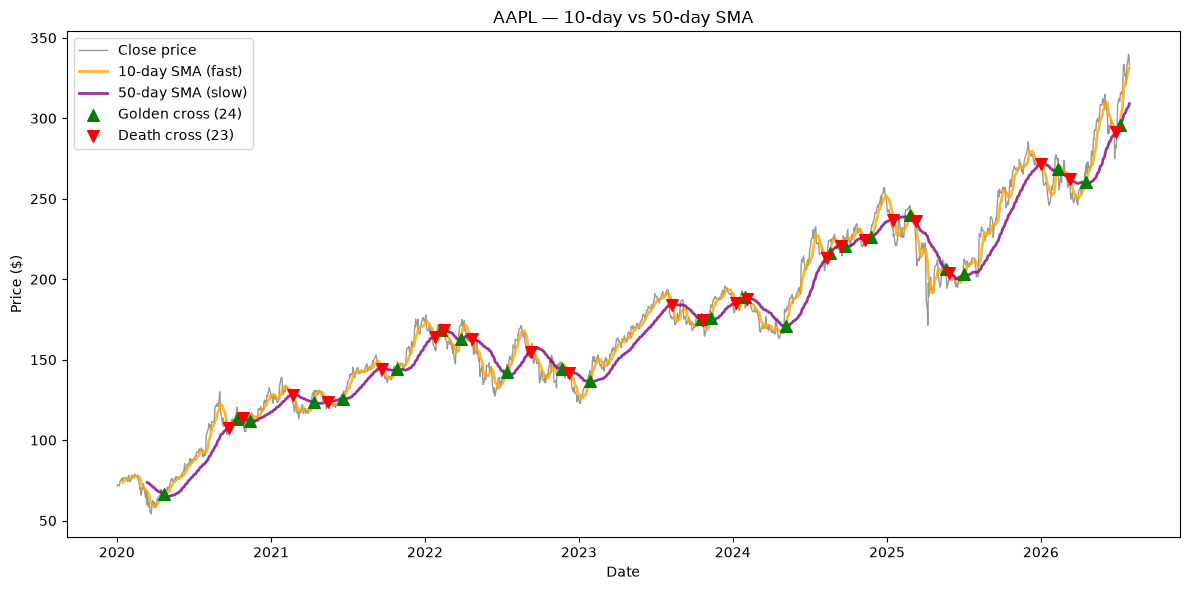

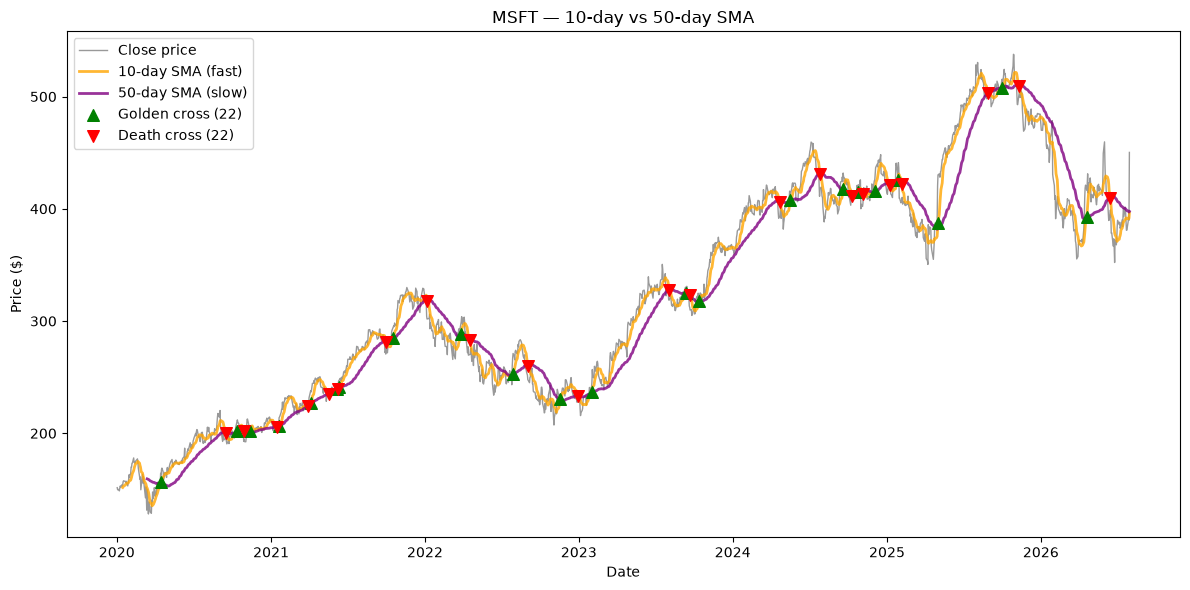

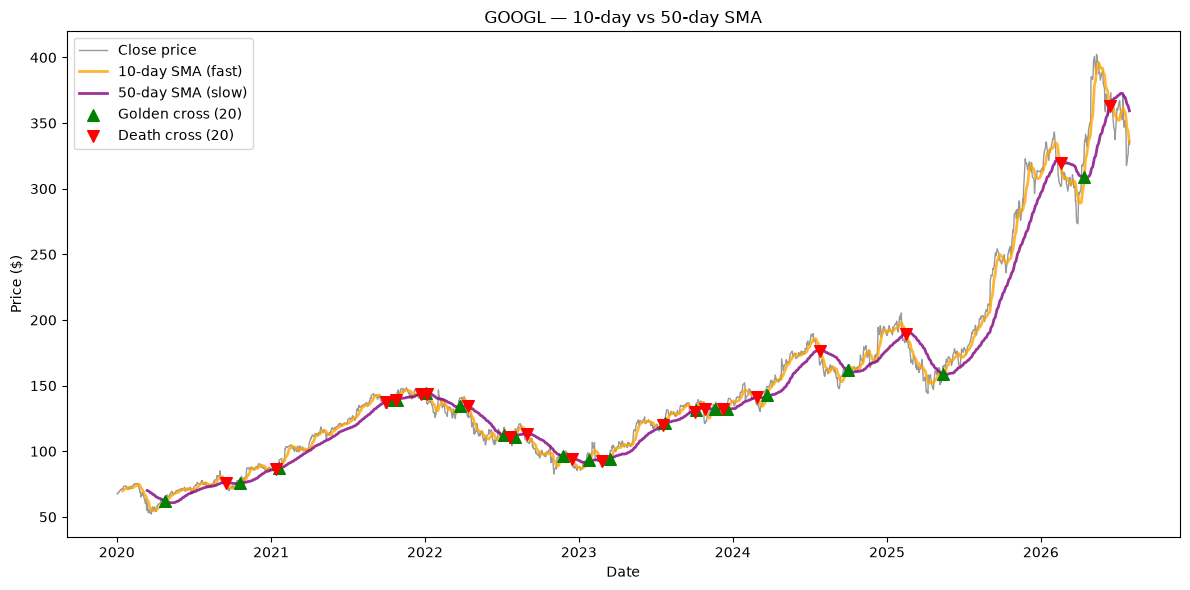

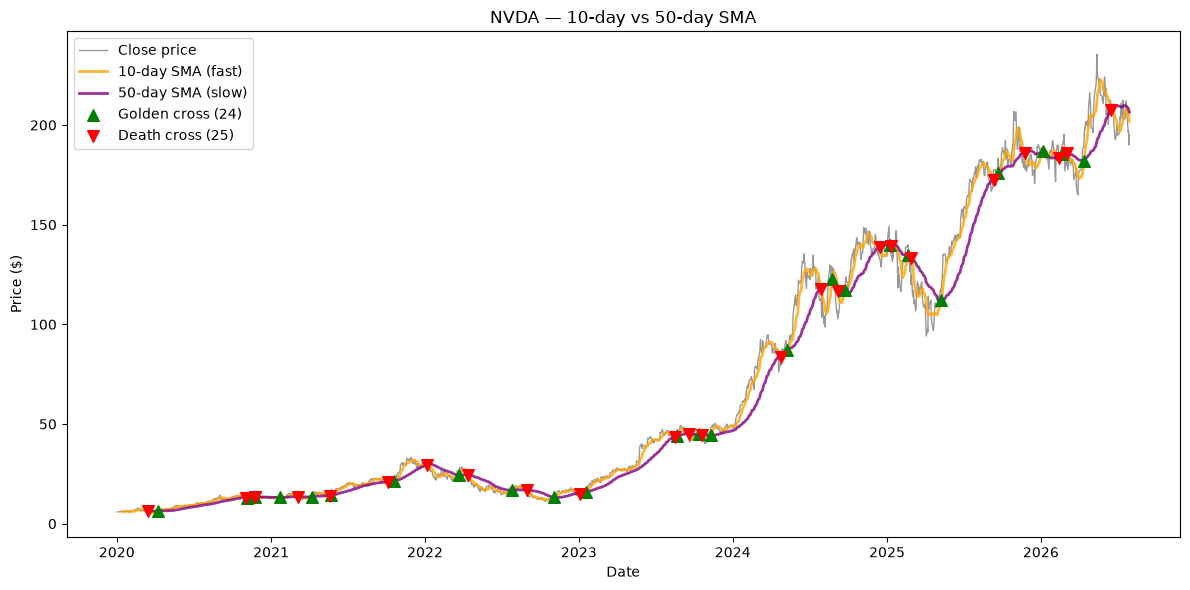

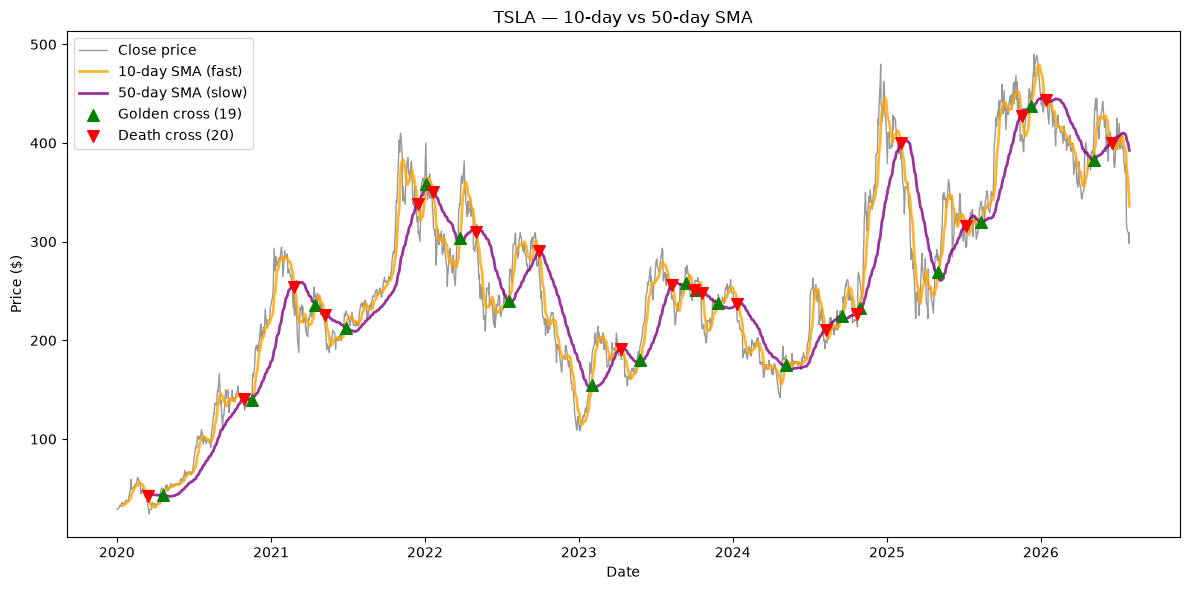

In [88]:
# The loop variable is `frame`: naming it `df` would overwrite the multi-ticker panel
# downloaded in section 2 and break section 4 on a re-run.
for ticker, frame in stock_dfs.items():
    plot_sma_comparison(frame, ticker)

## 7 · Bollinger Bands

A 20-day moving average with a band drawn two rolling standard deviations above and below it. Because the width is driven by recent volatility, the envelope is a visual read on how turbulent each name has been.

Two patterns to look for:

- **Squeeze** — bands pinch together during quiet periods, which often precedes a larger move in either direction.
- **Band touch** — price reaching the upper or lower band signals a statistically unusual move relative to the last 20 days. On a trending stock price can ride a band for weeks, so a touch is not on its own a reversal signal.

In [89]:
def plot_bollinger_bands(df, ticker):
    """Plot close price inside its 20-day, 2-standard-deviation envelope."""
    df = df.copy()

    plt.figure(figsize=[12, 6])

    plt.plot(df.index, df['Close'],
             label='Close price',
             c='black',
             linewidth=1.5,
             alpha=0.8)

    plt.plot(df.index, df['MiddleBand'],
             label='Middle band (20-day SMA)',
             c='blue',
             linewidth=1.5,
             alpha=0.7)

    plt.plot(df.index, df['UpperBand'],
             label='Upper band (+2σ)',
             c='orange',
             linewidth=1,
             alpha=0.7)

    plt.plot(df.index, df['LowerBand'],
             label='Lower band (−2σ)',
             c='purple',
             linewidth=1,
             alpha=0.7)

    # Shading makes squeezes (narrow band) and expansions (wide band) easier to spot
    # than four separate lines.
    plt.fill_between(df.index, df['LowerBand'], df['UpperBand'],
                     color='steelblue', alpha=0.12)

    plt.title(f'{ticker} — Bollinger Bands (20-day, 2σ)')
    plt.xlabel('Date')
    plt.ylabel('Price ($)')
    plt.legend()
    plt.tight_layout()
    plt.show()

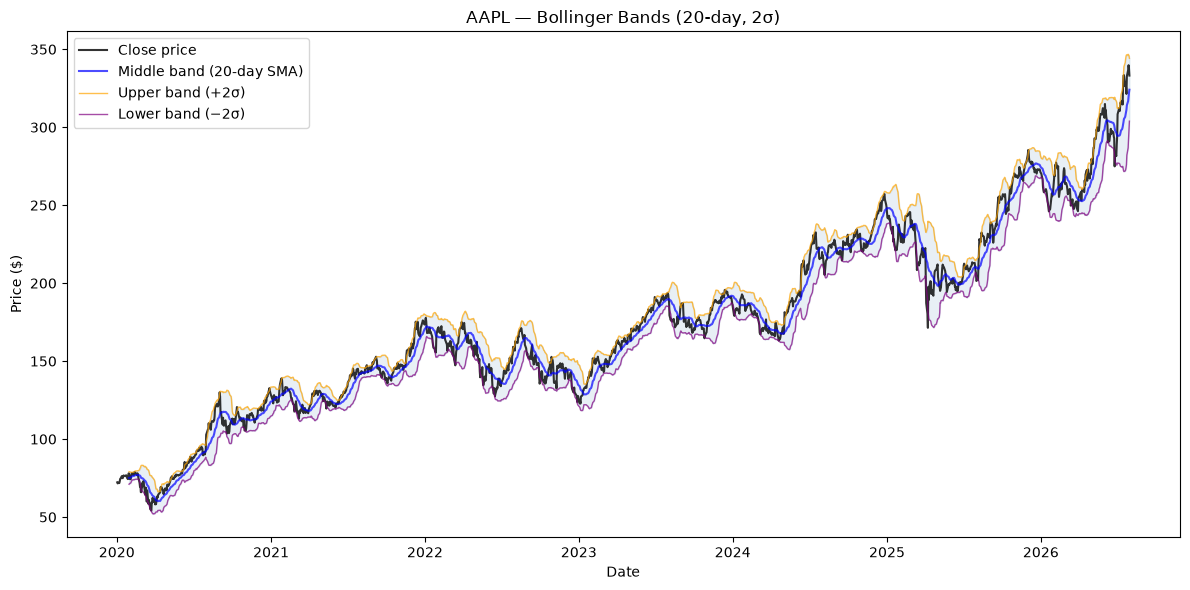

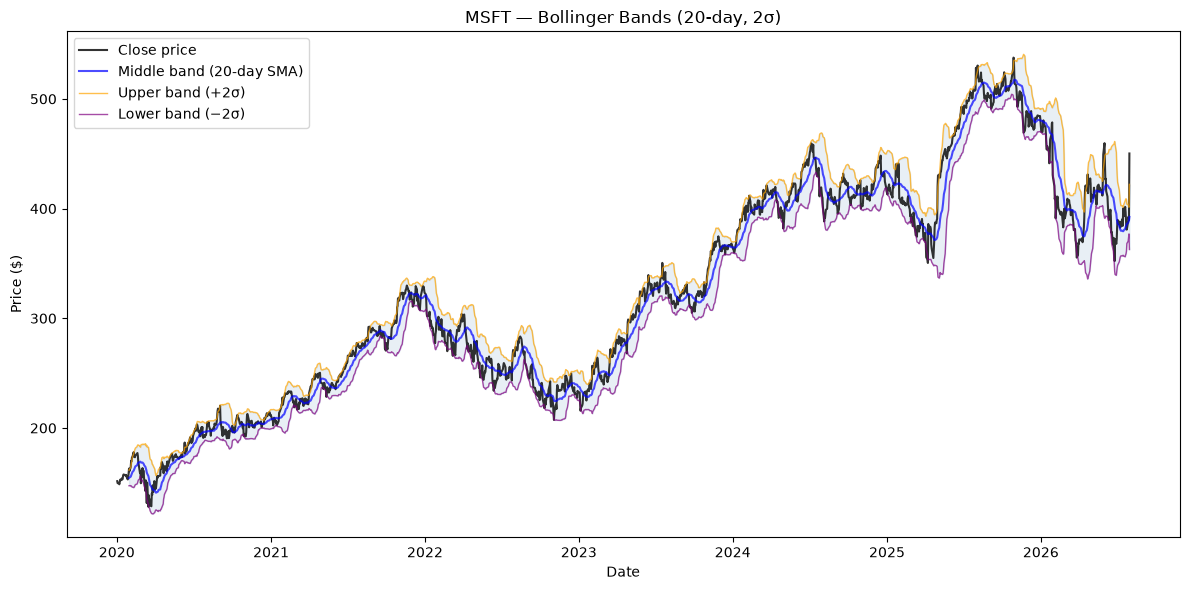

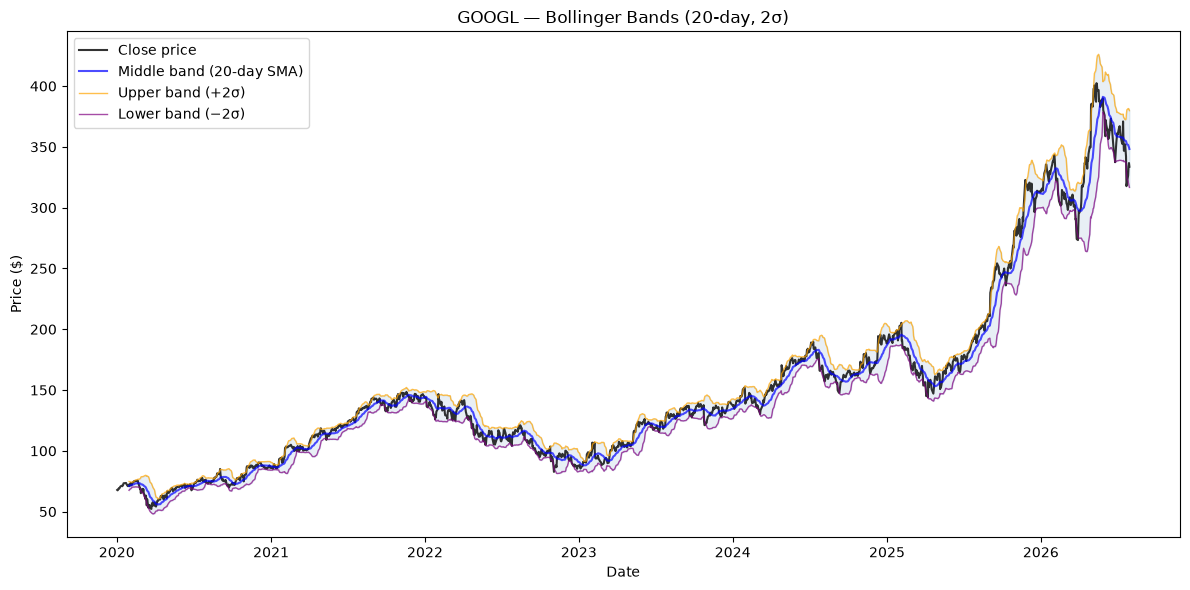

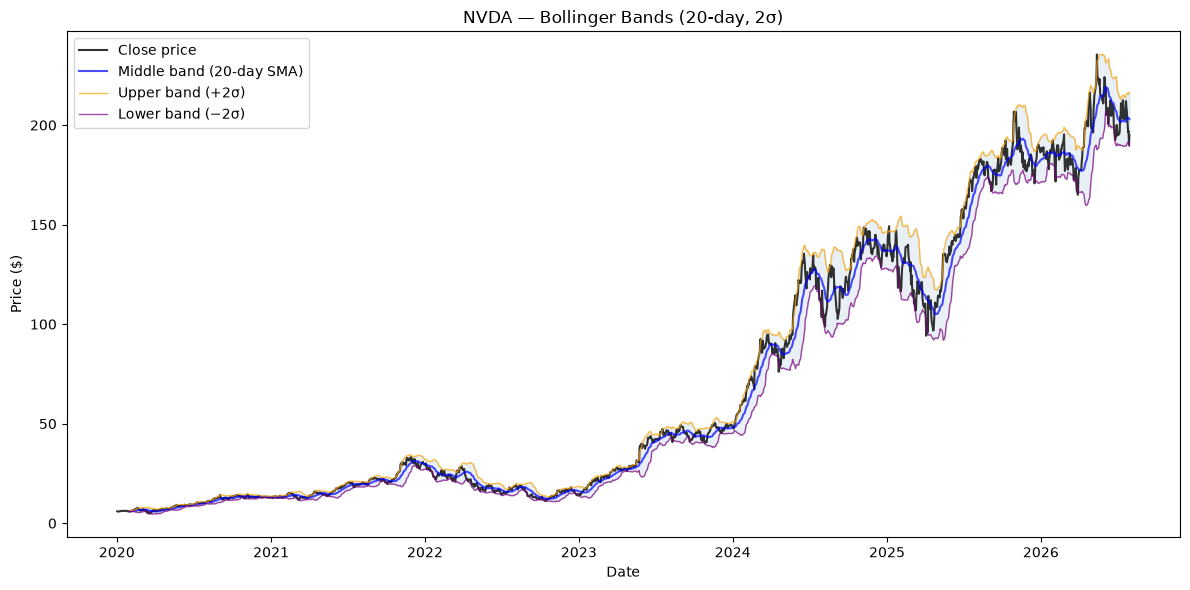

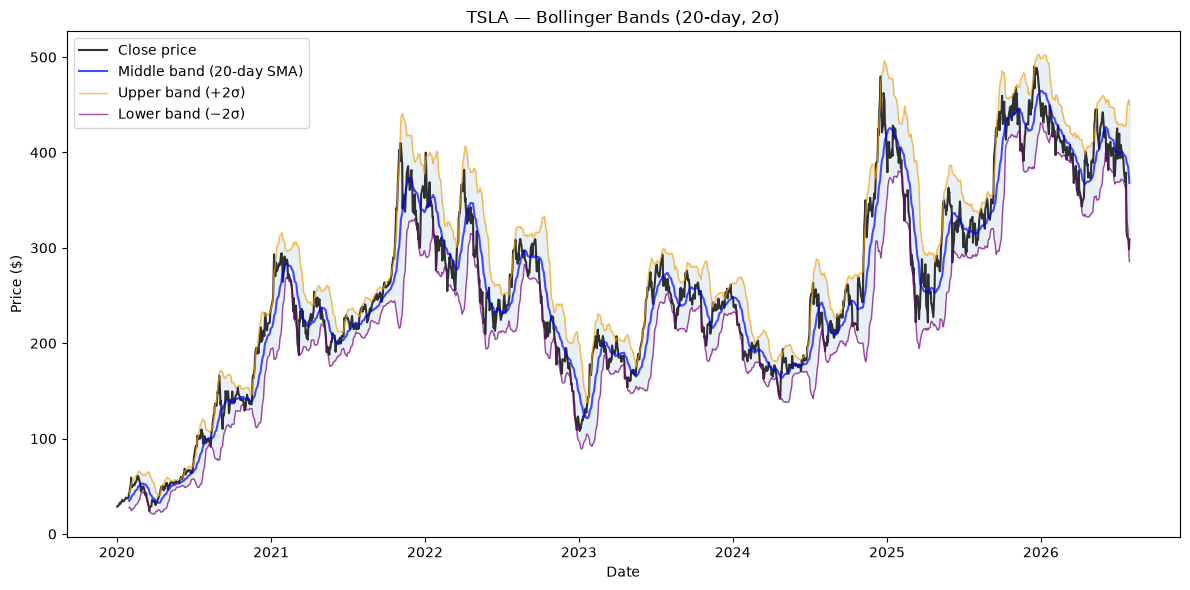

In [90]:
for ticker, frame in stock_dfs.items():
    plot_bollinger_bands(frame, ticker)

## 8 · MACD

Moving Average Convergence Divergence, the standard (12, 26, 9) configuration. Three series, all built in section 5:

| Series | Definition | Reads as |
| --- | --- | --- |
| `MACD` | 12-day EMA − 26-day EMA | Trend direction and strength |
| `Signal` | 9-day EMA of `MACD` | A smoothed benchmark for the MACD line |
| Histogram | `MACD` − `Signal` | The gap a crossover is about to close |

Two independent signals appear on the lower panel:

- **Line crossover** — MACD crossing above its signal line (green ▲) is the conventional bullish trigger; crossing below (red ▼) is bearish. Detected the same way as the SMA crosses in section 6, by testing whether the sign of `MACD − Signal` flipped since yesterday.
- **Zero-line cross** — MACD above zero simply means the 12-day EMA sits above the 26-day one. This is the slower, more durable of the two signals, since it describes the trend itself rather than a shift in momentum.

**Why two panels.** MACD is a *difference* between two EMAs, so it is measured in dollars of EMA spread and oscillates around zero. It cannot share an axis with the close price, which is why the earlier charts plotted price directly but this one splits the figure. Crossovers are marked on the price panel as well so each signal can be judged against the move that actually followed.

**Compared with section 6.** Both sections detect trend changes from a fast/slow average pair, but MACD uses exponential averages, which weight recent prices more heavily and react sooner than the simple averages behind the golden and death crosses. Expect more MACD signals as a result — and the same whipsaw caveat applies, more so. In a sideways market the two lines cross constantly.

In [ ]:
def plot_macd(df, ticker):
    """Plot price above the MACD line, its signal line, and their histogram.

    Two panels sharing an x-axis, because MACD is a difference between two EMAs and
    therefore lives in price-change units, not price levels — it cannot share an axis
    with the close. Crossovers are marked on both panels so each signal can be read
    against the move that followed it.
    """
    df = df.copy()

    """ 
    Histogram is the gap a crossover closes: it shrinks toward zero as the lines
    converge and flips sign on the day they cross.
    """
    hist = df['MACD'] - df['Signal']
    prev_hist = hist.shift(1)

    # Same sign-flip test used for the SMA crossovers in section 6.
    bullish = (prev_hist < 0) & (hist >= 0)   # MACD rises through its signal line
    bearish = (prev_hist > 0) & (hist <= 0)   # MACD falls through its signal line

    fig, (ax_price, ax_macd) = plt.subplots(
        2, 1,
        figsize=[12, 8],
        sharex=True,
        gridspec_kw={'height_ratios': [2, 1]},
    )

    ax_price.plot(df.index, df['Close'],
                  label='Close price', c='black', linewidth=1.5, alpha=0.8)
    ax_price.scatter(df.index[bullish], df.loc[bullish, 'Close'],
                     marker='^', s=45, c='green', zorder=5,
                     label=f'Bullish crossover ({int(bullish.sum())})')
    ax_price.scatter(df.index[bearish], df.loc[bearish, 'Close'],
                     marker='v', s=45, c='red', zorder=5,
                     label=f'Bearish crossover ({int(bearish.sum())})')
    ax_price.set_ylabel('Price ($)')
    ax_price.set_title(f'{ticker} — MACD (12, 26, 9)')
    ax_price.legend(loc='upper left', fontsize=8)

    ax_macd.bar(df.index, hist,
                color=np.where(hist >= 0, 'green', 'red'),
                alpha=0.3, width=1.0, label='Histogram (MACD − signal)')
    ax_macd.plot(df.index, df['MACD'],
                 label='MACD (12-day EMA − 26-day EMA)', c='blue', linewidth=1.5, alpha=0.8)
    ax_macd.plot(df.index, df['Signal'],
                 label='Signal (9-day EMA of MACD)', c='orange', linewidth=1.5, alpha=0.8)
    # Above zero the 12-day EMA sits above the 26-day one, so the zero line separates
    # uptrend from downtrend and is a second, slower signal than the crossovers.
    ax_macd.axhline(0, color='gray', linewidth=0.8, linestyle='--')
    ax_macd.set_ylabel('EMA difference ($)')
    ax_macd.set_xlabel('Date')
    ax_macd.legend(loc='upper left', fontsize=8)

    plt.tight_layout()
    plt.show()

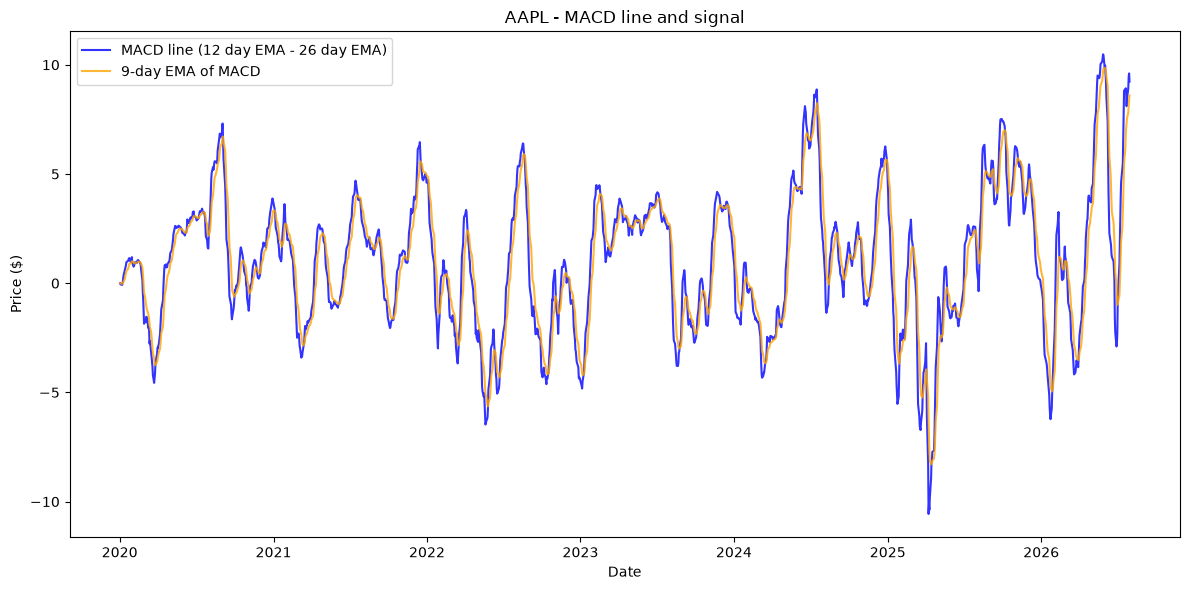

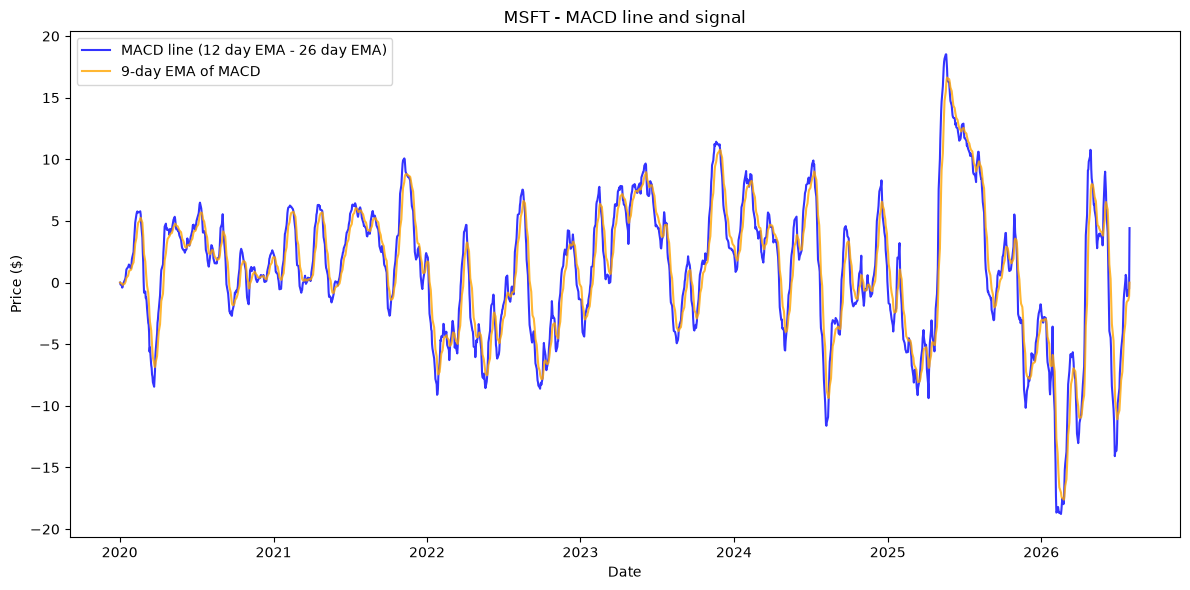

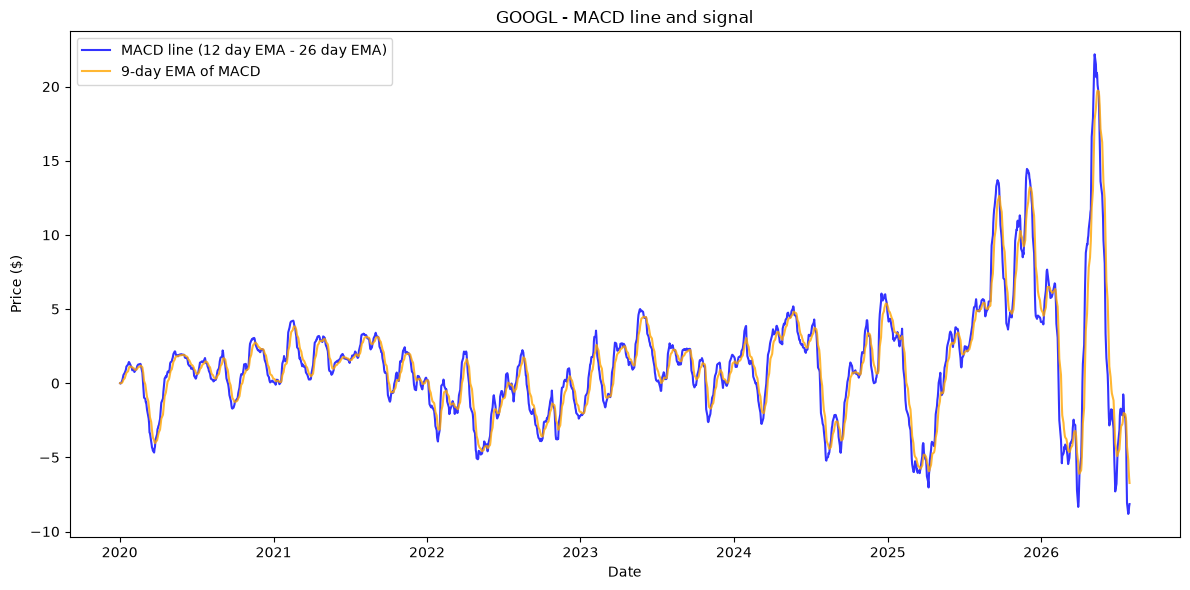

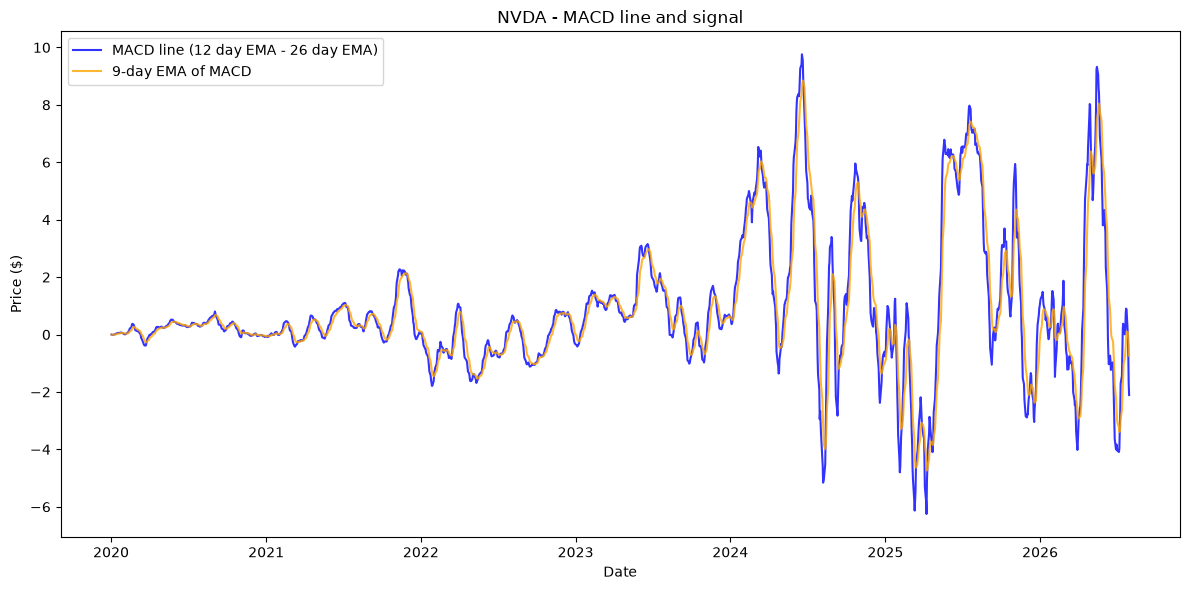

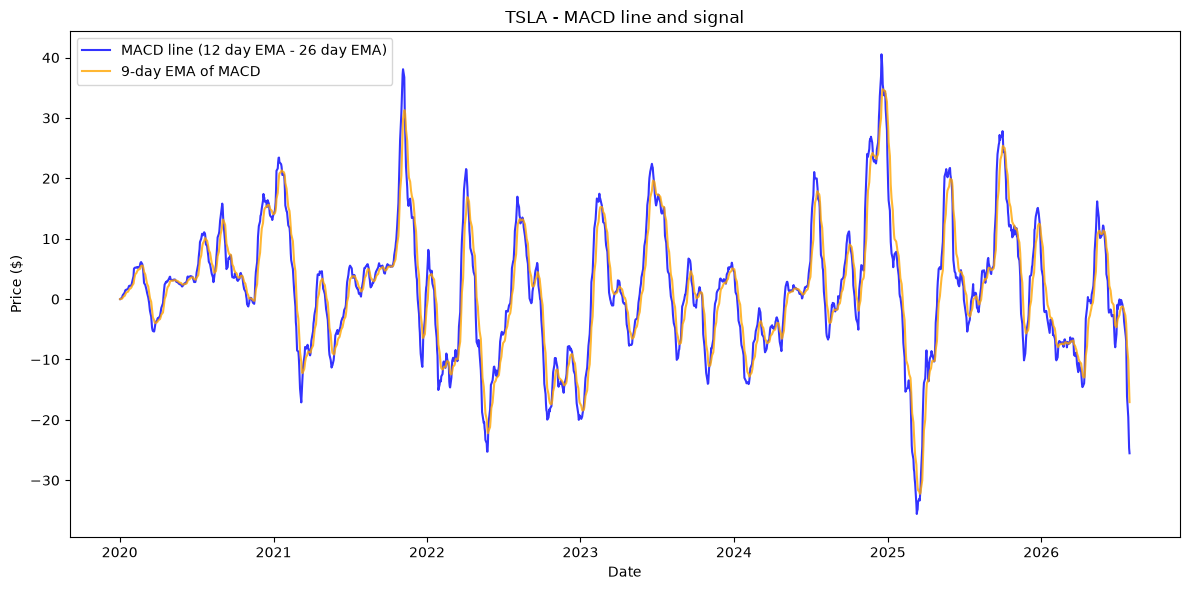

In [96]:
for ticker, frame in stock_dfs.items():
    plot_macd(frame, ticker)


# Part 2 — Portfolio construction

Part 1 looked at each stock on its own. Part 2 asks how to hold all five together.

These names are all large-cap US technology stocks, so **sector diversification is limited** no matter how the weights are set. Weighting still matters, because an equal-dollar book puts most of its *risk* in the most volatile names — typically NVDA and TSLA.

Everything below runs off the adjusted close panel in `data`. Portfolios are long-only and fully invested (weights ≥ 0, summing to 1).

---

## 9 · Portfolio inputs: risk, return, and correlation

Three inputs drive every weighting scheme that follows:

- **Expected return** — the mean daily return scaled by 252. This is an *arithmetic* annualization, so it runs higher than the compound growth rate actually realized.
- **Volatility** — the daily standard deviation scaled by √252, the usual square-root-of-time convention.
- **Covariance** — how the names move together. This is what makes diversification work at all: combining two imperfectly correlated stocks gives a portfolio less volatile than the weighted average of its parts.

Correlations above roughly 0.6 mean two names offer each other little protection.

### The risk-free rate

Sharpe ratios need a risk-free rate, and rather than hardcode one, the next cell pulls the **3-month Treasury constant maturity yield** (`DGS3MO`) live from the St. Louis Fed's FRED database. The 3-month bill is the standard proxy for the risk-free asset: short enough that duration and default risk are negligible.

The fetch uses FRED's public CSV endpoint, so it needs no API key and no package beyond pandas. If the request fails the cell falls back to a fixed 4% and prints a warning, so the notebook still runs offline.

**Which rate to use is a real choice, not a formality.** The cell computes two:

| Variable | Meaning |
| --- | --- |
| `RISK_FREE_CURRENT` | The most recent published yield |
| `RISK_FREE_WINDOW` | The average yield across the return window |

These are far apart, because the T-bill went from roughly zero in 2020–2021 to above 5% in 2023 before easing. The chart below shows the full path.

`RISK_FREE` defaults to the **current** rate, which answers "what does this portfolio's track record look like against cash today." The window average is arguably the better match for an in-sample Sharpe, since it is the cash return an investor could actually have earned over the same period being measured. Set `RISK_FREE = RISK_FREE_WINDOW` in the cell to switch.

**What the choice actually affects.** For any fixed set of portfolios the rate shifts every Sharpe ratio by roughly the same amount, so their *ranking* is unchanged — inverse volatility does not overtake equal weight because you switched rates.

It does move one thing: the max-Sharpe portfolio that section 11 *selects* out of the random cloud. That portfolio is the tangency portfolio, and where the tangency line touches the frontier depends on the rate it starts from. A lower risk-free rate shifts the pick slightly away from the highest-return name. This is correct finance rather than instability, but it is worth knowing that the "optimal" book is partly a function of an input fetched from outside the price data.

In [ ]:
FRED_SERIES = 'DGS3MO'        # 3-month Treasury constant maturity, daily, in percent
FALLBACK_RISK_FREE = 0.04     # used only if FRED cannot be reached


def fetch_fred_series(series_id, start, end=None):
    """Download one FRED series as a decimal rate indexed by observation date.

    Uses FRED's public CSV endpoint, which needs no API key and no extra dependency
    beyond pandas. FRED publishes yields in percent, so the result is divided by 100.
    Non-trading days come back as NaN and are dropped.
    """
    url = (
        'https://fred.stlouisfed.org/graph/fredgraph.csv'
        f'?id={series_id}&cosd={start}'
    )
    if end is not None:
        url += f'&coed={end}'
    frame = pd.read_csv(url, parse_dates=['observation_date'])
    return frame.set_index('observation_date')[series_id].dropna() / 100


# Fetched through the latest available date rather than stopping at end_date, so
# "current" means current. The window average is sliced back to the return period.
try:
    tbill = fetch_fred_series(FRED_SERIES, start_date)
    RISK_FREE_CURRENT = float(tbill.iloc[-1])
    RISK_FREE_WINDOW = float(tbill.loc[:end_date].mean())
    print(f'FRED {FRED_SERIES}: {len(tbill):,} observations from {tbill.index[0]:%Y-%m-%d}')
    print(f'  current ({tbill.index[-1]:%Y-%m-%d})      : {RISK_FREE_CURRENT:.2%}')
    print(f'  average over return window : {RISK_FREE_WINDOW:.2%}')
    print(f'  range over return window   : {tbill.loc[:end_date].min():.2%} to {tbill.loc[:end_date].max():.2%}')
except Exception as exc:
    # Keeps the notebook runnable offline instead of failing the whole of Part 2.
    tbill = None
    RISK_FREE_CURRENT = RISK_FREE_WINDOW = FALLBACK_RISK_FREE
    print(f'FRED unreachable ({type(exc).__name__}: {exc}); '
          f'falling back to {FALLBACK_RISK_FREE:.2%}')

# Switch to RISK_FREE_WINDOW to price Sharpe against the cash rate that was actually
# available across the return period. See the note above for the tradeoff.
RISK_FREE = RISK_FREE_CURRENT

if tbill is not None:
    fig = px.line(
        tbill,
        title=f'3-month Treasury constant maturity ({FRED_SERIES}, FRED)',
        template='plotly_dark',
    )
    fig.add_hline(
        y=RISK_FREE_WINDOW,
        line_dash='dot',
        line_color='gray',
        annotation_text=f'window average {RISK_FREE_WINDOW:.2%}',
    )
    fig.update_layout(xaxis_title='Date', yaxis_title='Annual yield', showlegend=False)
    fig.update_yaxes(tickformat='.1%')
    fig.show()

In [91]:
TRADING_DAYS = 252   # approximate trading days in a calendar year
# RISK_FREE comes from the FRED cell above and feeds every Sharpe ratio below.

close = data.copy()
# Simple (not log) daily returns. dropna() removes the first row, which has no prior
# close to difference against.
returns = close.pct_change().dropna()

# Every weight vector in this notebook is ordered to match returns.columns.
assets = list(returns.columns)
n_assets = len(assets)

# Annualize: means scale linearly with time, standard deviations with its square root.
mean_ann = returns.mean() * TRADING_DAYS
vol_ann = returns.std() * np.sqrt(TRADING_DAYS)
cov_ann = returns.cov() * TRADING_DAYS
corr = returns.corr()

# Compound growth rate actually realized, shown next to the arithmetic mean because the
# two diverge sharply for volatile names — the gap is the volatility drag.
years = len(returns) / TRADING_DAYS
cagr = (close.iloc[-1] / close.iloc[0]) ** (1 / years) - 1

asset_stats = pd.DataFrame({
    'Annual return': mean_ann,
    'Realized CAGR': cagr,
    'Annual volatility': vol_ann,
    'Sharpe': (mean_ann - RISK_FREE) / vol_ann,
})

display(
    asset_stats.style.format({
        'Annual return': '{:.2%}',
        'Realized CAGR': '{:.2%}',
        'Annual volatility': '{:.2%}',
        'Sharpe': '{:.2f}',
    }).set_caption(
        f'Standalone risk and return, {years:.1f} years in-sample '
        f'(risk-free {RISK_FREE:.2%})'
    )
)

# zmin/zmax are pinned to the full [-1, 1] range so the color scale is not rescaled to
# whatever the observed correlations happen to be, which would overstate the spread.
fig = px.imshow(
    corr,
    text_auto='.2f',
    color_continuous_scale='RdBu_r',
    zmin=-1,
    zmax=1,
    title='Daily return correlations',
    template='plotly_dark',
)
fig.update_layout(coloraxis_colorbar=dict(title='ρ'))
fig.show()

# Average off-diagonal correlation summarizes how much diversification is available.
off_diagonal = corr.where(~np.eye(n_assets, dtype=bool))
print(f'average pairwise correlation: {off_diagonal.stack().mean():.2f}')

,Annual return,Realized CAGR,Annual volatility,Sharpe
Ticker,,,,
AAPL,28.24%,26.27%,31.38%,0.77
MSFT,21.25%,18.08%,30.47%,0.57
GOOGL,29.59%,27.53%,32.47%,0.79
NVDA,66.74%,70.29%,52.07%,1.21
TSLA,57.42%,43.73%,65.13%,0.82


average pairwise correlation: 0.54


## 10 · Weighting strategies

Three rule-based books here, then two Monte Carlo optima in section 11.

| Strategy | Rule | Uses expected returns? |
| --- | --- | --- |
| Equal weight | 1/N in each name | No |
| Inverse volatility | weight ∝ 1/σ | No |
| Inverse variance | weight ∝ 1/σ² | No |

None of the three uses expected returns, and that is deliberate. Estimated means are far noisier than estimated variances, so weighting rules that chase past returns tend to concentrate into whatever name happened to run hardest.

**Capital weight is not risk weight.** This is the central point of the section. An equal-dollar book holds 20% of its *capital* in each stock but far more than 20% of its *risk* in the most volatile ones. The second chart below decomposes portfolio volatility into each name's share, computed as

\[ \text{risk share}_i = \frac{w_i (\Sigma w)_i}{\sigma_p^2} \]

which sums to 1 across the five holdings.

The book carried forward is **inverse volatility**: it thins out NVDA and TSLA without betting that this window's best performer keeps winning.

In [92]:
def normalize(weights):
    """Rescale to sum to 1, enforcing the fully-invested constraint."""
    weights = np.asarray(weights, dtype=float)
    return weights / weights.sum()


def equal_weights(n_assets):
    """1/N in every name."""
    return np.ones(n_assets) / n_assets


def inverse_vol_weights(return_frame):
    """Weight inversely to standard deviation — a one-line risk-parity approximation.

    Exact risk parity would also account for correlations; this ignores them, which is
    a close approximation when the names are similarly correlated to each other.
    """
    return normalize(1.0 / return_frame.std())


def inverse_var_weights(return_frame):
    """Weight inversely to variance. A stronger tilt toward the quietest names."""
    return normalize(1.0 / return_frame.var())


def portfolio_performance(weights, mean_ann, cov_ann, rf=RISK_FREE):
    """Annualized return, volatility, and Sharpe for one weight vector.

    Volatility is the quadratic form sqrt(w' Σ w), which is what captures the
    diversification benefit — it is below the weighted average of individual
    volatilities whenever correlations are under 1.

    Weights must be ordered to match the rows of mean_ann and cov_ann.
    """
    weights = np.asarray(weights, dtype=float)
    mean_ann = np.asarray(mean_ann, dtype=float)
    cov_ann = np.asarray(cov_ann, dtype=float)
    ret = float(weights @ mean_ann)
    vol = float(np.sqrt(weights @ cov_ann @ weights))
    sharpe = (ret - rf) / vol
    return ret, vol, sharpe


def risk_contributions(weights, cov_ann):
    """Each holding's share of total portfolio risk, summing to 1.

    (Σw)_i / σ_p is holding i's marginal contribution to portfolio volatility;
    multiplying by w_i gives its total contribution. Those contributions sum exactly
    to σ_p (Euler's theorem), so dividing by the sum turns them into shares.
    """
    weights = np.asarray(weights, dtype=float)
    cov_ann = np.asarray(cov_ann, dtype=float)
    port_vol = np.sqrt(weights @ cov_ann @ weights)
    marginal = cov_ann @ weights / port_vol
    contrib = weights * marginal
    return contrib / contrib.sum()


def strategy_table(schemes, mean_ann, cov_ann, assets):
    """One row per strategy: performance metrics followed by the weights themselves."""
    rows = []
    for name, weights in schemes.items():
        ret, vol, sharpe = portfolio_performance(weights, mean_ann, cov_ann)
        rows.append({
            'Strategy': name,
            'Expected return': ret,
            'Volatility': vol,
            'Sharpe': sharpe,
            **{asset: weight for asset, weight in zip(assets, weights)},
        })
    return pd.DataFrame(rows).set_index('Strategy')


# Section 11 adds two more entries to this dict, so re-running that cell alone is safe
# but re-running this one resets the schemes back to the three heuristics.
weight_schemes = {
    'Equal weight': equal_weights(n_assets),
    'Inverse volatility': inverse_vol_weights(returns),
    'Inverse variance': inverse_var_weights(returns),
}

heuristic_table = strategy_table(weight_schemes, mean_ann, cov_ann, assets)
display(
    heuristic_table.style.format({
        'Expected return': '{:.2%}',
        'Volatility': '{:.2%}',
        'Sharpe': '{:.2f}',
        **{asset: '{:.1%}' for asset in assets},
    }).set_caption('Heuristic long-only weights')
)

# Capital weights vs risk shares, side by side. The gap between the two charts below is
# the argument for not holding an equal-dollar book.
rc_heuristic = pd.DataFrame(
    {name: risk_contributions(weights, cov_ann) for name, weights in weight_schemes.items()},
    index=assets,
)

weight_long = (
    pd.DataFrame(weight_schemes, index=assets)
    .reset_index()
    .melt(id_vars='index', var_name='Strategy', value_name='Weight')
    .rename(columns={'index': 'Ticker'})
)
fig = px.bar(
    weight_long,
    x='Ticker',
    y='Weight',
    color='Strategy',
    barmode='group',
    title='Capital weights',
    template='plotly_dark',
)
fig.update_yaxes(tickformat='.0%')
fig.show()

rc_long = (
    rc_heuristic.reset_index()
    .melt(id_vars='index', var_name='Strategy', value_name='Risk share')
    .rename(columns={'index': 'Ticker'})
)
fig = px.bar(
    rc_long,
    x='Strategy',
    y='Risk share',
    color='Ticker',
    title='Risk contribution — equal weight vs inverse vol/var',
    template='plotly_dark',
)
fig.update_yaxes(tickformat='.0%')
fig.show()

,Expected return,Volatility,Sharpe,AAPL,MSFT,GOOGL,NVDA,TSLA
Strategy,,,,,,,,
Equal weight,40.65%,33.41%,1.10,20.0%,20.0%,20.0%,20.0%,20.0%
Inverse volatility,35.93%,30.57%,1.04,24.5%,25.2%,23.7%,14.8%,11.8%
Inverse variance,32.31%,28.95%,0.98,27.9%,29.5%,26.0%,10.1%,6.5%


## 11 · Monte Carlo I — random portfolios and the efficient frontier

**The question:** across every possible way to split capital among these five names, which combinations are worth holding?

Each of 25,000 trials draws a random long-only weight vector from a Dirichlet(1, …, 1) distribution, which is uniform over the simplex of fully invested books. Sampling this way is a brute-force stand-in for a constrained optimizer: with only five assets the cloud traces the frontier closely enough to read off both optima, and it shows the whole feasible set rather than just its edge.

The **upper-left boundary** of the cloud is the efficient frontier — maximum return for a given level of risk. Two points are marked:

- **Max Sharpe** — best reward-to-risk *in this sample*. It typically loads heavily into whichever name ran hardest, which is a bet on past returns repeating rather than a diversification rule.
- **Min volatility** — the quietest fully invested book, similar in spirit to inverse variance.

Inverse volatility is plotted alongside them so you can see the cost of choosing diversification over in-sample optimality.

**Caveat:** the frontier is fitted on the same history it is evaluated against, so max-Sharpe is optimistic by construction. The growth chart at the end of the cell has the same problem — it is an in-sample backtest of a daily-rebalanced book, not a forecast.

In [93]:
RNG_SEED = 42
N_PORTFOLIOS = 25_000

# Dedicated generator so this cell reproduces the same frontier no matter what else
# has been run before it.
frontier_rng = np.random.default_rng(RNG_SEED)

# Dirichlet(1, ..., 1) is uniform over the simplex, giving long-only weights that sum
# to 1 without any rejection sampling.
mc_weights = frontier_rng.dirichlet(np.ones(n_assets), size=N_PORTFOLIOS)

# Column order of mc_weights matches assets, which matches mean_ann and cov_ann.
mc_ret = mc_weights @ mean_ann.values
# einsum evaluates the quadratic form w' Σ w for all 25,000 rows at once, avoiding a
# Python loop over portfolios.
mc_vol = np.sqrt(np.einsum('ij,jk,ik->i', mc_weights, cov_ann.values, mc_weights))
mc_sharpe = (mc_ret - RISK_FREE) / mc_vol

max_sharpe_i = int(np.argmax(mc_sharpe))
min_vol_i = int(np.argmin(mc_vol))

weight_schemes['Max Sharpe (MC)'] = mc_weights[max_sharpe_i]
weight_schemes['Min volatility (MC)'] = mc_weights[min_vol_i]

mc_table = strategy_table(weight_schemes, mean_ann, cov_ann, assets)
display(
    mc_table.style.format({
        'Expected return': '{:.2%}',
        'Volatility': '{:.2%}',
        'Sharpe': '{:.2f}',
        **{asset: '{:.1%}' for asset in assets},
    }).set_caption('All strategies, including Monte Carlo optima')
)

markers = {
    'Equal weight': 'circle',
    'Inverse volatility': 'diamond',
    'Inverse variance': 'square',
    'Max Sharpe (MC)': 'star',
    'Min volatility (MC)': 'x',
}

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=mc_vol,
    y=mc_ret,
    mode='markers',
    name='Random portfolios',
    marker=dict(
        size=4,
        color=mc_sharpe,
        colorscale='Viridis',
        colorbar=dict(
            title=dict(text='Sharpe', side='right'),
            x=1.02,
            len=0.7,
            thickness=14,
            y=0.5,
            yanchor='middle',
        ),
        opacity=0.4,
    ),
    legendgroup='random',
    hovertemplate='Vol: %{x:.1%}<br>Return: %{y:.1%}<extra></extra>',
))

for name, weights in weight_schemes.items():
    ret, vol, sharpe = portfolio_performance(weights, mean_ann, cov_ann)
    fig.add_trace(go.Scatter(
        x=[vol],
        y=[ret],
        mode='markers',
        name=name,
        legendgroup=name,
        marker=dict(size=14, symbol=markers.get(name, 'circle')),
        hovertemplate=(
            f'{name}<br>Vol: %{{x:.1%}}<br>Return: %{{y:.1%}}'
            f'<br>Sharpe: {sharpe:.2f}<extra></extra>'
        ),
    ))

fig.update_layout(
    template='plotly_dark',
    title='Monte Carlo feasible set (25,000 long-only portfolios)',
    xaxis_title='Annual volatility',
    yaxis_title='Annual expected return',
    height=680,
    margin=dict(r=260, t=70, l=70, b=60),
    legend=dict(
        title=dict(text='Book'),
        x=1.18,
        y=1,
        xanchor='left',
        yanchor='top',
        font=dict(size=13),
        itemsizing='constant',
        itemwidth=40,
        tracegroupgap=22,
        bgcolor='rgba(0,0,0,0)',
    ),
)
fig.update_xaxes(tickformat='.0%')
fig.update_yaxes(tickformat='.0%')
fig.show()

# In-sample backtest. The matrix product applies fixed weights to every day's returns,
# which implicitly assumes the book is rebalanced back to target daily — a real
# portfolio would drift between rebalances and pay transaction costs.
growth = (1 + returns @ pd.DataFrame(weight_schemes, index=assets)).cumprod()
fig = px.line(
    growth,
    title='Growth of $1 by strategy (in-sample backtest — not a forecast)',
    labels={'value': 'Growth of $1', 'variable': 'Strategy'},
    template='plotly_dark',
)
fig.update_layout(yaxis_title='Growth of $1', xaxis_title='Date')
fig.show()

# Maximum drawdown: worst peak-to-trough loss each book actually lived through.
drawdown = growth / growth.cummax() - 1
display(
    drawdown.min().to_frame('Max drawdown').style
    .format('{:.1%}')
    .set_caption('Worst peak-to-trough decline, in-sample')
)

,Expected return,Volatility,Sharpe,AAPL,MSFT,GOOGL,NVDA,TSLA
Strategy,,,,,,,,
Equal weight,40.65%,33.41%,1.10,20.0%,20.0%,20.0%,20.0%,20.0%
Inverse volatility,35.93%,30.57%,1.04,24.5%,25.2%,23.7%,14.8%,11.8%
Inverse variance,32.31%,28.95%,0.98,27.9%,29.5%,26.0%,10.1%,6.5%
Max Sharpe (MC),59.74%,44.98%,1.24,3.4%,0.8%,10.3%,69.5%,16.0%
Min volatility (MC),25.52%,27.29%,0.79,37.2%,43.5%,19.1%,0.1%,0.0%


,Max drawdown
Equal weight,-46.6%
Inverse volatility,-42.2%
Inverse variance,-39.2%
Max Sharpe (MC),-58.6%
Min volatility (MC),-33.9%


## 12 · Monte Carlo II — bootstrapped forward paths

Section 11 asked which mix looked best over the past. **This section asks a different question: how wide is the range of outcomes for the book we chose?**

Each of 5,000 paths draws 252 daily returns *with replacement* from the inverse-volatility book's own realized history, then compounds them from a $10,000 start. Resampling actual days rather than drawing from a fitted normal distribution means the fat tails and crash days that really happened stay in the sampling pool. This is **not** geometric Brownian motion with an invented drift.

Two things the summary table reports:

- **VaR (5%)** — the 5th percentile of ending wealth. 95% of paths finish above this level.
- **CVaR (5%)** — the average ending wealth *within* that worst 5%, which describes how bad the bad case gets rather than just where it starts.

**Known limitation.** Drawing days independently destroys volatility clustering — real markets string calm days together and crash days together. That makes this simulation understate the odds of a sustained drawdown. A block bootstrap, which resamples multi-day chunks, would preserve that structure.

Max Sharpe is simulated alongside so the extra dispersion you accept for a higher median is visible.

In [94]:
N_PATHS = 5_000
HORIZON = 252            # one trading year
INITIAL = 10_000         # starting capital in dollars
CHOSEN = 'Inverse volatility'    # the diversified book being stressed
COMPARE = 'Max Sharpe (MC)'      # benchmark for how much extra dispersion it carries

# Its own generator, so re-running this cell alone reproduces the same paths instead of
# consuming wherever the section 11 generator happened to leave off.
boot_rng = np.random.default_rng(RNG_SEED + 1)


def bootstrap_paths(daily_returns, n_paths, horizon, initial, rng):
    """Compound `horizon` days resampled with replacement, for `n_paths` scenarios.

    Returns a (horizon, n_paths) array of portfolio values. Draws are independent
    across days, so volatility clustering is not preserved.
    """
    draws = rng.choice(daily_returns, size=(horizon, n_paths), replace=True)
    return initial * np.cumprod(1 + draws, axis=0)


def path_summary(paths, initial, name):
    """Distribution statistics for the final row of a simulated path array."""
    terminal = paths[-1]
    # 5% VaR expressed as a wealth level: 95% of paths end above it.
    var_5 = np.percentile(terminal, 5)
    # CVaR averages only the paths inside that worst 5% tail.
    tail = terminal[terminal <= var_5]
    return pd.Series({
        'Median ending wealth': np.median(terminal),
        '5th percentile (VaR)': var_5,
        '95th percentile': np.percentile(terminal, 95),
        'Expected shortfall (CVaR 5%)': tail.mean() if len(tail) else np.nan,
        'P(end below start)': (terminal < initial).mean(),
        'Median return': np.median(terminal) / initial - 1,
    }, name=name)


# Series indexed by `assets` so the matrix product below aligns on ticker name rather
# than on position.
chosen_w = pd.Series(weight_schemes[CHOSEN], index=assets)
compare_w = pd.Series(weight_schemes[COMPARE], index=assets)

# Collapse each book to a single daily return series, then bootstrap that series. This
# preserves the cross-sectional correlations, since every draw is a real trading day.
chosen_daily = (returns @ chosen_w).values
compare_daily = (returns @ compare_w).values

chosen_paths = bootstrap_paths(chosen_daily, N_PATHS, HORIZON, INITIAL, boot_rng)
compare_paths = bootstrap_paths(compare_daily, N_PATHS, HORIZON, INITIAL, boot_rng)

display(
    pd.concat([
        path_summary(chosen_paths, INITIAL, CHOSEN),
        path_summary(compare_paths, INITIAL, COMPARE),
    ], axis=1).style.format({
        CHOSEN: '{:,.2f}',
        COMPARE: '{:,.2f}',
    }).format('{:.1%}', subset=pd.IndexSlice[['P(end below start)', 'Median return'], :])
    .set_caption(f'One-year bootstrap from ${INITIAL:,.0f}')
)

days = np.arange(1, HORIZON + 1)
# Percentiles taken across paths (axis=1) at each day, so the bands are a cross-sectional
# snapshot per day rather than any single simulated path.
p5, p25, p50, p75, p95 = np.percentile(chosen_paths, [5, 25, 50, 75, 95], axis=1)

fig = go.Figure()
# Each band is drawn as a single closed polygon: the upper percentile forward, then the
# lower percentile reversed, with fill='toself' closing the shape.
fig.add_trace(go.Scatter(
    x=np.concatenate([days, days[::-1]]),
    y=np.concatenate([p95, p5[::-1]]),
    fill='toself',
    fillcolor='rgba(99, 110, 250, 0.15)',
    line=dict(width=0),
    name='5–95% band',
    hoverinfo='skip',
))
fig.add_trace(go.Scatter(
    x=np.concatenate([days, days[::-1]]),
    y=np.concatenate([p75, p25[::-1]]),
    fill='toself',
    fillcolor='rgba(99, 110, 250, 0.30)',
    line=dict(width=0),
    name='25–75% band',
    hoverinfo='skip',
))
fig.add_trace(go.Scatter(
    x=days, y=p50, mode='lines', name='Median path',
    line=dict(color='#636EFA', width=2),
))
fig.add_hline(y=INITIAL, line_dash='dot', line_color='gray', annotation_text='Start')
fig.update_layout(
    template='plotly_dark',
    title=f'{CHOSEN}: {N_PATHS:,} bootstrap paths over {HORIZON} trading days',
    xaxis_title='Trading day',
    yaxis_title='Portfolio value ($)',
)
fig.show()

terminal_df = pd.DataFrame({
    CHOSEN: chosen_paths[-1],
    COMPARE: compare_paths[-1],
})
fig = px.histogram(
    terminal_df.melt(var_name='Strategy', value_name='Ending wealth'),
    x='Ending wealth',
    color='Strategy',
    barmode='overlay',
    opacity=0.65,
    nbins=60,
    title='Distribution of ending wealth after one year',
    template='plotly_dark',
)
fig.add_vline(x=INITIAL, line_dash='dot', line_color='white')
fig.show()

# Final allocation, with each holding's capital weight next to its share of portfolio
# risk. Inverse-vol weighting narrows the gap between the two columns but does not
# close it, because it ignores correlations.
alloc = chosen_w.rename('Weight').to_frame()
alloc['Risk share'] = risk_contributions(chosen_w, cov_ann)
display(alloc.style.format('{:.1%}').set_caption(f'Chosen diversified book: {CHOSEN}'))

fig = px.pie(
    alloc.reset_index().rename(columns={'index': 'Ticker'}),
    names='Ticker',
    values='Weight',
    title=f'{CHOSEN} allocation',
    template='plotly_dark',
)
fig.show()

,Inverse volatility,Max Sharpe (MC)
Median ending wealth,"13,709.84","16,380.41"
5th percentile (VaR),"8,323.31","7,720.22"
95th percentile,"22,745.74","35,093.94"
Expected shortfall (CVaR 5%),"7,448.93","6,467.38"
P(end below start),14.7%,14.0%
Median return,37.1%,63.8%


,Weight,Risk share
AAPL,24.5%,20.7%
MSFT,25.2%,21.1%
GOOGL,23.7%,20.2%
NVDA,14.8%,20.3%
TSLA,11.8%,17.6%


## 13 · Summary

**What was built.** A five-stock universe was reduced to annualized risk, return, and covariance inputs; three rule-based weighting schemes were compared against two Monte Carlo optima; and the selected book was stressed through a 5,000-path bootstrap of its own return history.

**What the results support**

- Equal capital weight is not equal risk weight. The most volatile holdings consume a share of portfolio risk well above their 20% capital allocation, which is the concrete reason to weight by something other than dollars.
- Inverse-volatility weighting narrows that gap without using expected returns, so it does not chase whichever name happened to run hardest in this window.
- The max-Sharpe portfolio sits higher on the frontier but concentrates into a single name, and the ending-wealth histogram shows the dispersion that concentration buys.

**What the results do not support**

- **Nothing here is out-of-sample.** Both the frontier and the growth backtest are fitted and evaluated on the same 2020-present window, which flatters max-Sharpe most of all. A walk-forward test — estimate weights on a trailing window, evaluate on the next period, roll forward — is the honest version.
- **The bootstrap understates sustained drawdowns.** Independent daily draws destroy volatility clustering. A block bootstrap would preserve it.
- **Reweighting five tech stocks is not diversification.** The average pairwise correlation printed in section 9 is the binding constraint: these names fall together. Bonds, international equity, or other sectors are how you diversify beyond this universe.
- Transaction costs, taxes, and rebalancing drift are all ignored. The backtest assumes free daily rebalancing.

**Extending this**

Change `CHOSEN` in section 12 to stress a different book. Natural next steps are a walk-forward evaluation, a block bootstrap, a closed-form optimizer such as SLSQP to replace random sampling, and weight caps to keep any single name under a fixed ceiling.